# 🏙️ Smart City Cyber Attack Simulation System

## 🤖 AI-Based Network Pathfinding & Attack Analysis

---

### 📘 Course Information
- Course: Artificial Intelligence (CSC 262)  
- University: COMSATS University Islamabad, Abbottabad Campus  
- Campus: Dhamtour Campus  
- Instructor: Zeenat Zulfiqar  
- Email: zeenatzulfiqar@cuiatd.edu.pk  

---

### 👨‍💻 Project Description
This project simulates cyber attacks in a smart city environment using Artificial Intelligence search algorithms.

The system models a smart city as a weighted graph where:
- Nodes represent smart systems (Traffic, Hospital, Banking, Power Grid, etc.)
- Edges represent communication paths
- Weights represent risk or cost of traversal

The attacker starts from an entry node and tries to reach a critical target (Power Grid) using different AI algorithms.

---

### 🧠 Algorithms Implemented
- Breadth First Search (BFS)
- Depth First Search (DFS)
- Uniform Cost Search (UCS)
- A* Search Algorithm
- Hill Climbing
- Minimax Algorithm
- Alpha-Beta Pruning

---

### 🎯 Objective
To compare different AI search strategies in terms of:
- Path optimality
- Execution time
- Nodes expanded
- Efficiency in cyber attack simulation

Problem Statement
Modern smart cities rely on interconnected systems such as traffic control, hospitals, banking systems, and power grids. These systems are vulnerable to cyber attacks.

This project models the smart city as a weighted graph where:

Nodes represent city systems
Edges represent communication paths
Weights represent risk/cost of attack
The objective is to simulate how an attacker moves from an entry point to a critical target system using different AI search algorithms and compare their efficiency.

In [4]:
# ==============================
# SMART CITY NETWORK GRAPH
# ==============================
# Nodes represent smart city systems
# Edges represent attack paths
# Weights represent risk/cost of traversal
import time
import heapq
import pandas as pd
from collections import deque

graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'D': 7, 'E': 3},
    'C': {'D': 1, 'F': 5},
    'D': {'G': 6},
    'E': {'G': 4, 'H': 3},
    'F': {'I': 2},
    'H': {'G': 2},
    'I': {'G': 1},
    'G': {}
}

In [5]:
# ==============================
# HEURISTIC VALUES (A* SEARCH)
# ==============================
# Estimated cost from each node to target (Power Grid)
heuristic = {
    'A': 7, 'B': 6, 'C': 5, 'D': 4,
    'E': 3, 'F': 6, 'H': 2, 'I': 1,
    'G': 0
}

In [6]:
# ==============================
# PERFORMANCE METRICS CLASS
# ==============================
# Tracks:
# - Nodes expanded
# - Execution time
class Metrics:
    def __init__(self):
        self.nodes_expanded = 0
        self.start_time = 0
        self.end_time = 0

    def start(self):
        self.start_time = time.time()

    def end(self):
        self.end_time = time.time()

    def time_ms(self):
        return round((self.end_time - self.start_time) * 1000, 2)

In [7]:
# ==============================
# BREADTH FIRST SEARCH (BFS)
# ==============================
# Finds shortest path in terms of steps (not cost)
def bfs(graph, start, goal):
    m = Metrics()
    m.start()

    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]
        m.nodes_expanded += 1

        if node == goal:
            m.end()
            return path, len(path), m.nodes_expanded, m.time_ms()

        if node not in visited:
            visited.add(node)
            for n in graph[node]:
                queue.append(path + [n])

In [8]:
# ==============================
# DEPTH FIRST SEARCH (DFS)
# ==============================
# Explores deep paths first
def dfs(graph, start, goal):
    m = Metrics()
    m.start()

    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        node = path[-1]
        m.nodes_expanded += 1

        if node == goal:
            m.end()
            return path, len(path), m.nodes_expanded, m.time_ms()

        if node not in visited:
            visited.add(node)
            for n in graph[node]:
                stack.append(path + [n])

In [9]:
# ==============================
# UNIFORM COST SEARCH (UCS)
# ==============================
# Finds lowest cost path
def ucs(graph, start, goal):
    m = Metrics()
    m.start()

    pq = [(0, [start])]
    visited = {}

    while pq:
        cost, path = heapq.heappop(pq)
        node = path[-1]
        m.nodes_expanded += 1

        if node == goal:
            m.end()
            return path, cost, m.nodes_expanded, m.time_ms()

        if node not in visited or cost < visited[node]:
            visited[node] = cost
            for n, w in graph[node].items():
                heapq.heappush(pq, (cost + w, path + [n]))

In [10]:
# ==============================
# A* SEARCH ALGORITHM
# ==============================
# f(n) = g(n) + h(n)
def astar(graph, start, goal, h):
    m = Metrics()
    m.start()

    pq = [(h[start], 0, [start])]

    while pq:
        f, g, path = heapq.heappop(pq)
        node = path[-1]
        m.nodes_expanded += 1

        if node == goal:
            m.end()
            return path, g, m.nodes_expanded, m.time_ms()

        for n, w in graph[node].items():
            new_g = g + w
            new_f = new_g + h[n]
            heapq.heappush(pq, (new_f, new_g, path + [n]))

In [11]:
# ==============================
# HILL CLIMBING (LOCAL SEARCH)
# ==============================
# Chooses best local move only
# May get stuck in local optimum
def hill_climbing(graph, start, goal, h):
    m = Metrics()
    m.start()

    current = start
    path = [current]

    while current != goal:
        m.nodes_expanded += 1
        neighbors = graph[current]

        if not neighbors:
            break

        next_node = min(neighbors, key=lambda x: h[x])

        # failure case (local maximum)
        if h[next_node] >= h[current]:
            break

        current = next_node
        path.append(current)

    m.end()
    return path, len(path), m.nodes_expanded, m.time_ms()

In [12]:
# ==============================
# MINIMAX (ATTACKER vs DEFENDER)
# ==============================
def minimax(node, depth, maximizing):
    if depth == 0 or node == 'G':
        return heuristic[node]

    if maximizing:
        best = -999
        for n in graph[node]:
            best = max(best, minimax(n, depth-1, False))
        return best
    else:
        best = 999
        for n in graph[node]:
            best = min(best, minimax(n, depth-1, True))
        return best

In [13]:
# ==============================
# ALPHA-BETA PRUNING
# ==============================
# Optimized Minimax
def alphabeta(node, depth, alpha, beta, maximizing):
    if depth == 0 or node == 'G':
        return heuristic[node]

    if maximizing:
        value = -999
        for n in graph[node]:
            value = max(value, alphabeta(n, depth-1, alpha, beta, False))
            alpha = max(alpha, value)
            if alpha >= beta:
                break
        return value
    else:
        value = 999
        for n in graph[node]:
            value = min(value, alphabeta(n, depth-1, alpha, beta, True))
            beta = min(beta, value)
            if alpha >= beta:
                break
        return value

In [14]:
def run_all():
    results = []

    for name, func in [
        ("BFS", bfs),
        ("DFS", dfs),
        ("UCS", ucs),
        ("A*", lambda g,s,g2: astar(g,s,g2,heuristic)),
        ("Hill Climbing", lambda g,s,g2: hill_climbing(g,s,g2,heuristic))
    ]:
        path, cost, nodes, t = func(graph, 'A', 'G')
        results.append([name, path, cost, nodes, t])

    return results

results = run_all()

In [15]:
df = pd.DataFrame(results, columns=[
    "Algorithm", "Path", "Cost", "Nodes Expanded", "Time(ms)"
])

df

,Algorithm,Path,Cost,Nodes Expanded,Time(ms)
0,BFS,"[A, B, D, G]",4,8,0.04
1,DFS,"[A, C, F, I, G]",5,5,0.01
2,UCS,"[A, B, E, G]",9,8,0.03
3,A*,"[A, B, E, G]",9,6,0.02
4,Hill Climbing,"[A, C, D, G]",4,3,0.02


In [16]:
!pip install networkx matplotlib

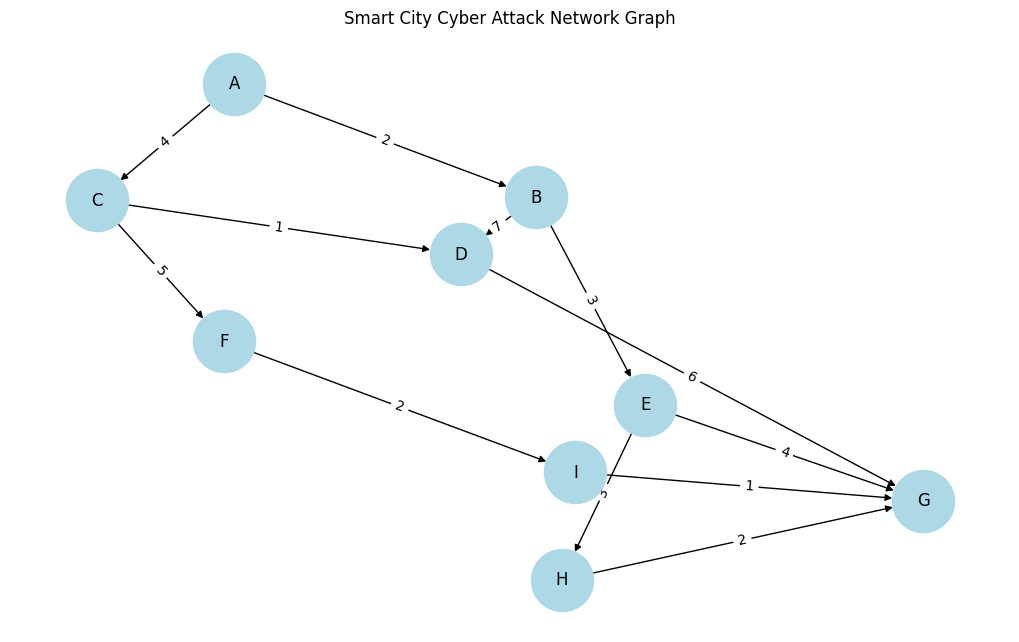

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# ==============================
# CREATE GRAPH FROM DICTIONARY
# ==============================
G = nx.DiGraph()

for node in graph:
    for neighbor, weight in graph[node].items():
        G.add_edge(node, neighbor, weight=weight)

# ==============================
# NODE POSITION (LAYOUT)
# ==============================
pos = nx.spring_layout(G, seed=42)

# ==============================
# DRAW GRAPH
# ==============================
plt.figure(figsize=(10,6))

nx.draw(G, pos, with_labels=True, node_color="lightblue",
        node_size=2000, font_size=12, arrows=True)

# EDGE LABELS (WEIGHTS)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Smart City Cyber Attack Network Graph")
plt.show()


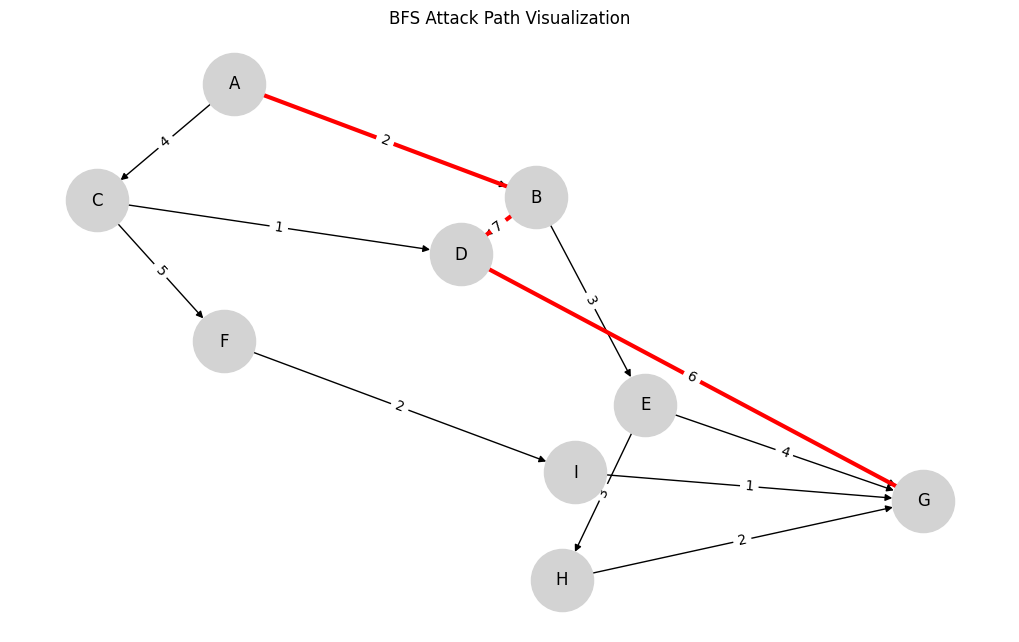

In [18]:
path = bfs(graph, 'A', 'G')[0]

edges_path = list(zip(path, path[1:]))

plt.figure(figsize=(10,6))
nx.draw(G, pos, with_labels=True, node_color="lightgray",
        node_size=2000, arrows=True)

nx.draw_networkx_edges(G, pos, edgelist=edges_path,
                        width=3, edge_color="red")

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("BFS Attack Path Visualization")
plt.show()

In [19]:
# =========================================
# NETWORK PATH VISUALIZATION FUNCTION
# =========================================
# This function creates a graph visualization
# and highlights the discovered attack path
def show_path(path, title, color):
    import matplotlib.pyplot as plt
    import networkx as nx

    G = nx.DiGraph()

    for node in graph:
        for nbr, w in graph[node].items():
            G.add_edge(node, nbr)

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10,6))

    nx.draw(G, pos, with_labels=True, node_color="lightgray",
            node_size=2000, arrows=True)

    edges = list(zip(path, path[1:]))

    nx.draw_networkx_edges(G, pos, edgelist=edges,
                           edge_color=color, width=3)

    plt.title(title)
    plt.show()



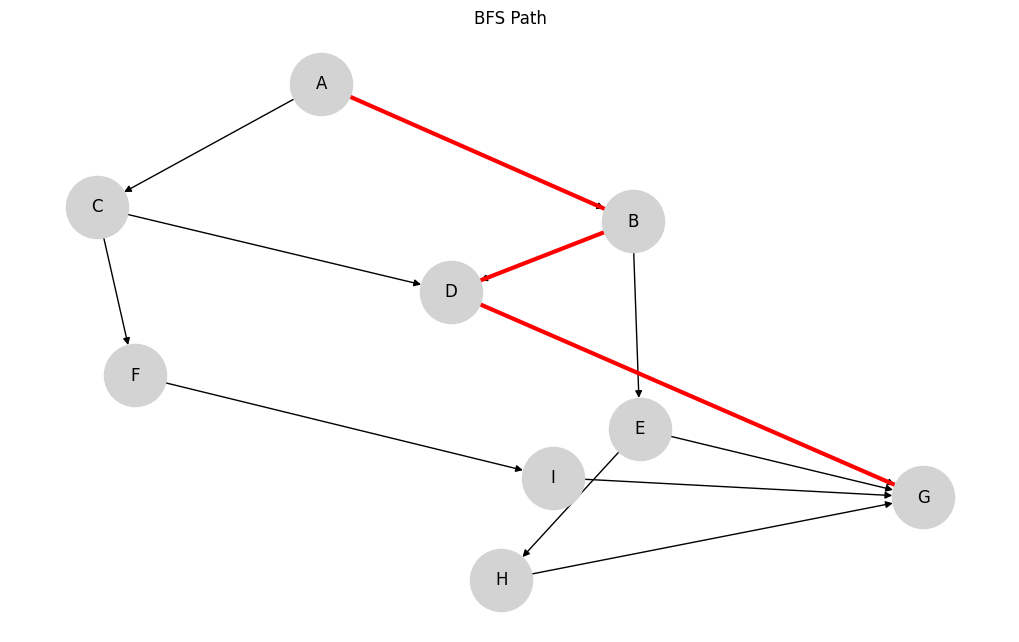

In [20]:
# =========================================
# BFS ATTACK PATH VISUALIZATION
# =========================================
# Visualizes attack route discovered by BFS
bfs_path = bfs(graph,'A','G')[0]
show_path(bfs_path, "BFS Path", "red")

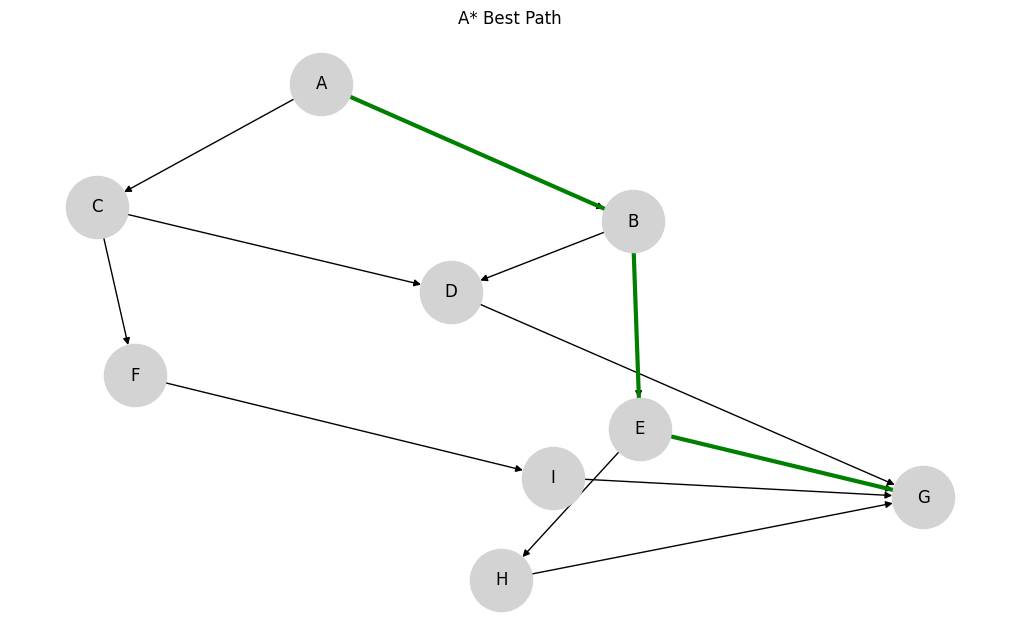

In [21]:
# =========================================
# A* OPTIMAL PATH VISUALIZATION
# =========================================
# Visualizes best heuristic-based attack path
astar_path = astar(graph,'A','G',heuristic)[0]
show_path(astar_path, "A* Best Path", "green")

# 🚨 Smart City Cyber Attack Simulation Execution

This section executes the selected AI algorithm and visualizes the cyber attack path inside the smart city network.


🚨 SMART CITY CYBER ATTACK SIMULATION
--------------------------------------
Selected Algorithm: A*
Attack Path: ['A', 'B', 'E', 'G']
Total Cost: 9
Nodes Expanded: 6
Execution Time: 0.03 ms


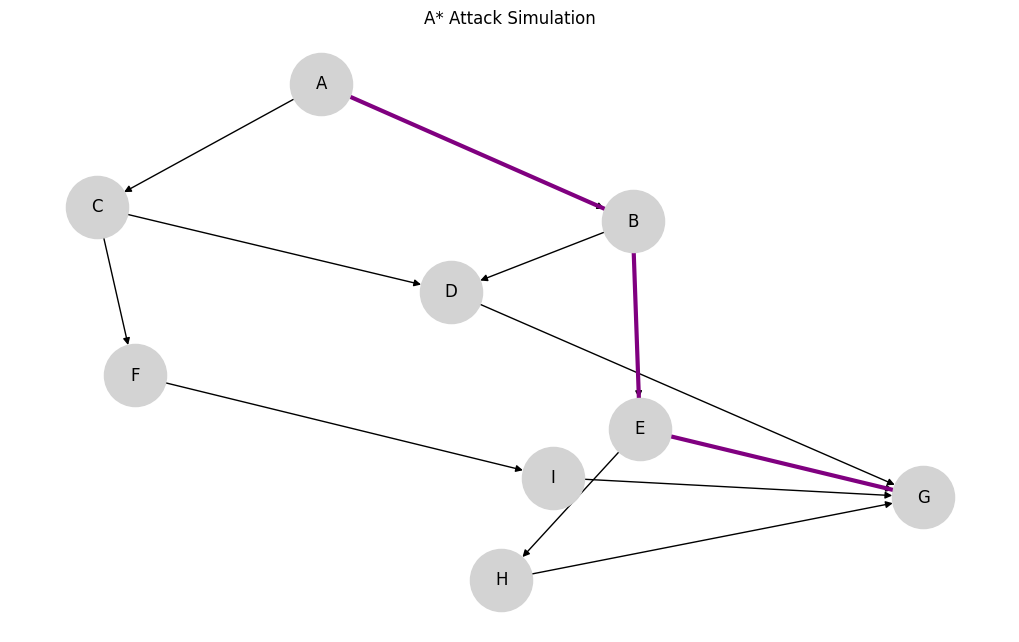

In [22]:
# =========================================
# MAIN CYBER ATTACK SIMULATION SYSTEM
# =========================================

algorithm = "A*"   # Change algorithm here

# Execute Selected Algorithm

if algorithm == "BFS":
    path, cost, nodes, t = bfs(graph,'A','G')
    color = "red"

elif algorithm == "DFS":
    path, cost, nodes, t = dfs(graph,'A','G')
    color = "blue"

elif algorithm == "UCS":
    path, cost, nodes, t = ucs(graph,'A','G')
    color = "green"

elif algorithm == "A*":
    path, cost, nodes, t = astar(graph,'A','G',heuristic)
    color = "purple"

elif algorithm == "Hill":
    path, cost, nodes, t = hill_climbing(graph,'A','G',heuristic)
    color = "orange"

# Display Results

print("\n🚨 SMART CITY CYBER ATTACK SIMULATION")
print("--------------------------------------")

print("Selected Algorithm:", algorithm)
print("Attack Path:", path)
print("Total Cost:", cost)
print("Nodes Expanded:", nodes)
print("Execution Time:", t, "ms")

# Visualize Path

show_path(
    path,
    algorithm + " Attack Simulation",
    color
)

In [23]:
# =========================================
# ATTACK MOVEMENT SIMULATION
# =========================================

import time

print("\n🚨 Live Attack Movement:\n")

for node in path:
    print("➡ Attacker moved to:", node)
    time.sleep(1)

print("\n🎯 Critical Power Grid Compromised!")


🚨 Live Attack Movement:

➡ Attacker moved to: A
➡ Attacker moved to: B
➡ Attacker moved to: E
➡ Attacker moved to: G

🎯 Critical Power Grid Compromised!


📊 Final Analysis and Conclusion
This project successfully simulated cyber attack pathfinding in a smart city network using multiple Artificial Intelligence search algorithms.

The smart city systems were modeled as a weighted graph where nodes represented critical infrastructures such as hospitals, traffic systems, CCTV networks, banking systems, and power grids.

Different AI algorithms were implemented and compared based on:

Path optimality
Execution time
Nodes expanded
Cost efficiency
Key Findings
BFS successfully found shortest paths but explored many nodes.
DFS explored deep paths quickly but was not always optimal.
UCS produced the lowest cost path using weighted traversal.
A* Search performed best overall due to heuristic guidance.
Hill Climbing demonstrated local optimum failure.
Minimax and Alpha-Beta simulated attacker vs defender decision-making.
Conclusion
A* Search Algorithm achieved the best balance between efficiency, speed, and optimal path discovery in the smart city cyber attack simulation.

This project demonstrates the practical use of Artificial Intelligence algorithms in cybersecurity and smart infrastructure protection.

